In [1]:
# ============================================================
# Summer Total Alkalinity Time Series by Biome
# SOCAT vs SANAE vs CSIR-ML6
# Thesis-quality publication-ready figure
# ============================================================

# --- Load libraries ---
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


In [2]:
# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------
socat_path = "/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SOCAT/SOCAT_combined.xlsx"

sanae_path = "/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SANAE/SANAE_Combined_Underway_clean.xlsx"

csirml6_path = "/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/CSIR_ML6/CSIR_ML6_Final.nc"

# Excel datasets
df_socat = pd.read_excel(socat_path)
df_sanae = pd.read_excel(sanae_path)

# NetCDF dataset
ds_csirml6 = xr.open_dataset(csirml6_path)

# Convert NetCDF to dataframe
df_csirml6 = ds_csirml6.to_dataframe().reset_index()

In [3]:
# ------------------------------------------------------------
# Standardise column names
# ------------------------------------------------------------
# Adjust these names if needed depending on your .nc structure

df_csirml6 = df_csirml6.rename(columns={
    'latitude': 'Lat',
    'Latitude': 'Lat',
    'lat': 'Lat',

    'longitude': 'Lon',
    'Longitude': 'Lon',
    'lon': 'Lon',

    'time': 'Date',
    'TIME': 'Date',

    'TA': 'Total Alkalinity',
    'ta': 'Total Alkalinity',
    'total_alkalinity': 'Total Alkalinity'
})


In [4]:
# ------------------------------------------------------------
# Parse dates
# ------------------------------------------------------------
df_socat['Date'] = pd.to_datetime(df_socat['Date'])
df_sanae['Date'] = pd.to_datetime(df_sanae['Date'])
df_csirml6['Date'] = pd.to_datetime(df_csirml6['Date'])


In [5]:
# ------------------------------------------------------------
# Define biome assignment
# ------------------------------------------------------------
def assign_biome(lat):

    if -44 <= lat < -35:
        return "STSS (35–44°S)"

    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"

    elif -70 <= lat < -58:
        return "ICE (58–70°S)"

    else:
        return "Outside Defined Biome"


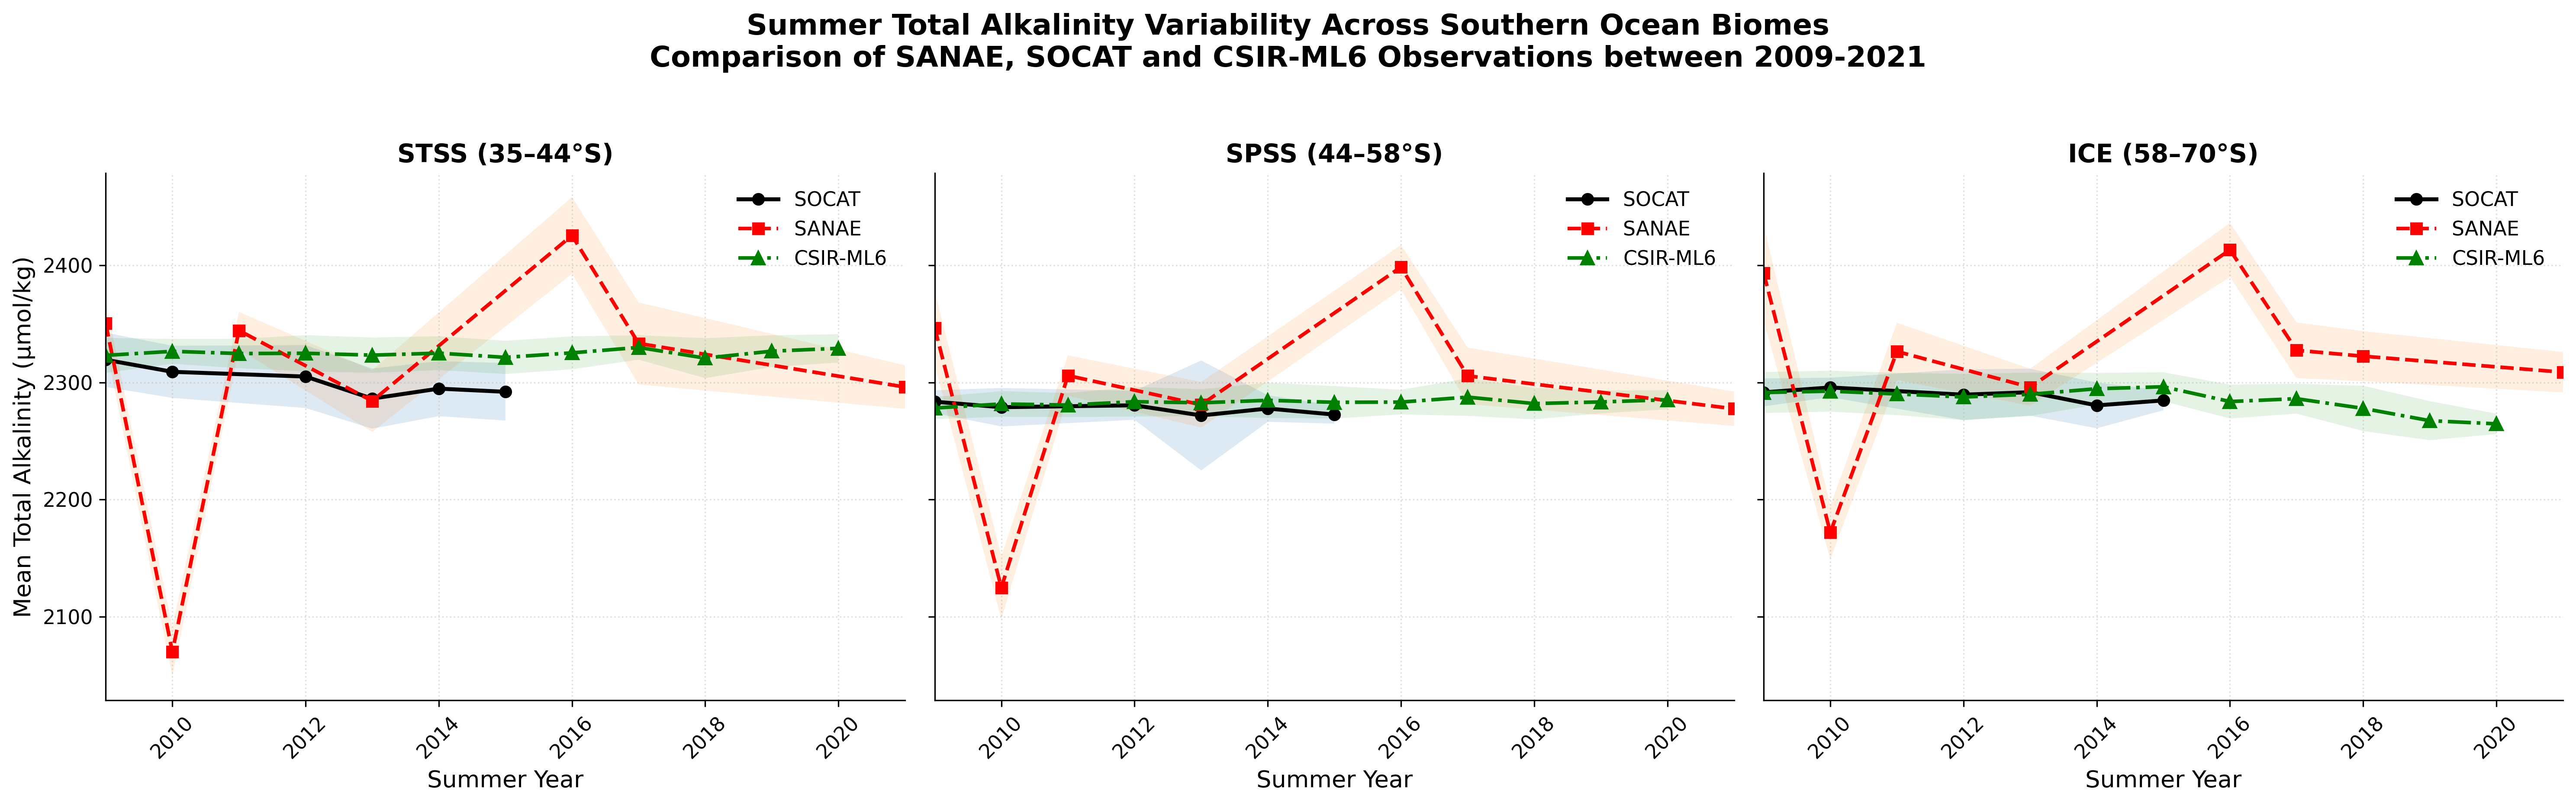


SOCAT Summary
   SummerYear           Biome         mean        std
0        2009   ICE (58–70°S)  2291.567797  11.948193
1        2009  SPSS (44–58°S)  2283.587310   9.760416
2        2009  STSS (35–44°S)  2319.368609  23.181918
3        2010   ICE (58–70°S)  2295.736795   8.337079
4        2010  SPSS (44–58°S)  2278.888970  16.393270

SANAE Summary
   SummerYear           Biome         mean        std
0        2009   ICE (58–70°S)  2393.338008  40.863381
1        2009  SPSS (44–58°S)  2346.629416  31.576347
2        2009  STSS (35–44°S)  2350.428311  18.768331
3        2010   ICE (58–70°S)  2171.960767  22.900768
4        2010  SPSS (44–58°S)  2124.757860  26.822359

CSIR-ML6 Summary
   SummerYear           Biome         mean        std
0        2009   ICE (58–70°S)  2291.415771  17.529295
1        2009  SPSS (44–58°S)  2278.170898   9.484277
2        2009  STSS (35–44°S)  2323.131592  14.946739
3        2010   ICE (58–70°S)  2292.584717  17.464014
4        2010  SPSS (44–58°S)  228

In [10]:
# ------------------------------------------------------------
# Define austral summer periods
# ------------------------------------------------------------
summer_ranges = {
    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# ------------------------------------------------------------
# Filter summer data
# ------------------------------------------------------------
def filter_summer(df):

    summer_dfs = []

    for year, (start, end) in summer_ranges.items():

        mask = (
            (df['Date'] >= pd.to_datetime(start)) &
            (df['Date'] <= pd.to_datetime(end))
        )

        temp = df.loc[mask].copy()
        temp['SummerYear'] = year

        summer_dfs.append(temp)

    return pd.concat(summer_dfs, ignore_index=True)

# Apply summer filter
df_socat_summer = filter_summer(df_socat)
df_sanae_summer = filter_summer(df_sanae)
df_csirml6_summer = filter_summer(df_csirml6)

# ------------------------------------------------------------
# Assign biomes
# ------------------------------------------------------------
df_socat_summer['Biome'] = df_socat_summer['Lat'].apply(assign_biome)
df_sanae_summer['Biome'] = df_sanae_summer['Lat'].apply(assign_biome)
df_csirml6_summer['Biome'] = df_csirml6_summer['Lat'].apply(assign_biome)

# ------------------------------------------------------------
# Keep only desired biomes
# ------------------------------------------------------------
biome_order = [
    "STSS (35–44°S)",
    "SPSS (44–58°S)",
    "ICE (58–70°S)"
]

df_socat_summer = df_socat_summer[
    df_socat_summer['Biome'].isin(biome_order)
]

df_sanae_summer = df_sanae_summer[
    df_sanae_summer['Biome'].isin(biome_order)
]

df_csirml6_summer = df_csirml6_summer[
    df_csirml6_summer['Biome'].isin(biome_order)
]

# ------------------------------------------------------------
# Ensure numeric TA
# ------------------------------------------------------------
datasets = [
    df_socat_summer,
    df_sanae_summer,
    df_csirml6_summer
]

for df in datasets:

    df['Total Alkalinity'] = pd.to_numeric(
        df['Total Alkalinity'],
        errors='coerce'
    )

# ------------------------------------------------------------
# Remove unrealistic TA values in ICE biome
# ------------------------------------------------------------
TA_min, TA_max = 2000, 2700

cleaned_datasets = []

for df in datasets:

    cleaned = df[
        ~(
            (df['Biome'] == "ICE (58–70°S)") &
            (
                (df['Total Alkalinity'] < TA_min) |
                (df['Total Alkalinity'] > TA_max)
            )
        )
    ]

    cleaned_datasets.append(cleaned)

df_socat_summer = cleaned_datasets[0]
df_sanae_summer = cleaned_datasets[1]
df_csirml6_summer = cleaned_datasets[2]

# ------------------------------------------------------------
# Compute mean and standard deviation
# ------------------------------------------------------------
soc_summary = (
    df_socat_summer
    .groupby(['SummerYear', 'Biome'])['Total Alkalinity']
    .agg(['mean', 'std'])
    .reset_index()
)

san_summary = (
    df_sanae_summer
    .groupby(['SummerYear', 'Biome'])['Total Alkalinity']
    .agg(['mean', 'std'])
    .reset_index()
)

ml6_summary = (
    df_csirml6_summer
    .groupby(['SummerYear', 'Biome'])['Total Alkalinity']
    .agg(['mean', 'std'])
    .reset_index()
)

# ------------------------------------------------------------
# Publication-quality plotting
# ------------------------------------------------------------
plt.rcParams.update({

    'font.family': 'sans-serif',
    'font.size': 12,

    'axes.labelsize': 13,
    'axes.titlesize': 14,

    'xtick.labelsize': 11,
    'ytick.labelsize': 11,

    'legend.fontsize': 11
})

# Biome colours
biome_colours = {
    "STSS (35–44°S)": "#ff7f0e",
    "SPSS (44–58°S)": "#2ca02c",
    "ICE (58–70°S)": "#1f77b4"
}

# Create figure
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    sharey=True,
    dpi=300
)

# ------------------------------------------------------------
# Plot each biome
# ------------------------------------------------------------
for i, biome in enumerate(biome_order):

    ax = axes[i]

    soc = soc_summary[soc_summary['Biome'] == biome]
    san = san_summary[san_summary['Biome'] == biome]
    ml6 = ml6_summary[ml6_summary['Biome'] == biome]

    colour = biome_colours[biome]

   

    # ---------------- SOCAT ----------------
    ax.plot(
        soc['SummerYear'],
        soc['mean'],
        color='black',
        linewidth=2.2,
        marker='o',
        markersize=6,
        label='SOCAT'
    )

    ax.fill_between(
        soc['SummerYear'],
        soc['mean'] - soc['std'],
        soc['mean'] + soc['std'],
        alpha=0.15
    )

   # ---------------- SANAE ----------------
    ax.plot(
        san['SummerYear'],
        san['mean'],
        color='red',
        linewidth=2,
        linestyle='--',
        marker='s',
        markersize=6,
        label='SANAE'
    )

    ax.fill_between(
        san['SummerYear'],
        san['mean'] - san['std'],
        san['mean'] + san['std'],
        alpha=0.12
    )
 

    # ---------------- CSIR-ML6 ----------------
    ax.plot(
        ml6['SummerYear'],
        ml6['mean'],
        color='green',
        linewidth=2,
        linestyle='-.',
        marker='^',
        markersize=7,
        label='CSIR-ML6'
    )

    ax.fill_between(
        ml6['SummerYear'],
        ml6['mean'] - ml6['std'],
        ml6['mean'] + ml6['std'],
        alpha=0.12
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    ax.set_title(
        biome,
        fontweight='bold'
    )

    ax.set_xlabel("Summer Year")

    if i == 0:
        ax.set_ylabel(
            "Mean Total Alkalinity (µmol/kg)"
        )

    ax.grid(
        True,
        linestyle=':',
        alpha=0.4
    )

    ax.set_xlim(2009, 2021)

    ax.xaxis.set_major_locator(
        mticker.MaxNLocator(integer=True)
    )

    ax.tick_params(axis='x', rotation=45)

    # Remove top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add legend
    ax.legend(frameon=False)

# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------
plt.suptitle(
    "Summer Total Alkalinity Variability Across Southern Ocean Biomes\n"
    "Comparison of SANAE, SOCAT and CSIR-ML6 Observations between 2009-2021",
    fontsize=16,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
plt.savefig(
    "Summer_Total_Alkalinity_Biomes_Thesis.png",
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    "Summer_Total_Alkalinity_Biomes_Thesis.pdf",
    bbox_inches='tight'
)

plt.show()

# ------------------------------------------------------------
# Optional: print summaries
# ------------------------------------------------------------
print("\nSOCAT Summary")
print(soc_summary.head())

print("\nSANAE Summary")
print(san_summary.head())

print("\nCSIR-ML6 Summary")
print(ml6_summary.head())

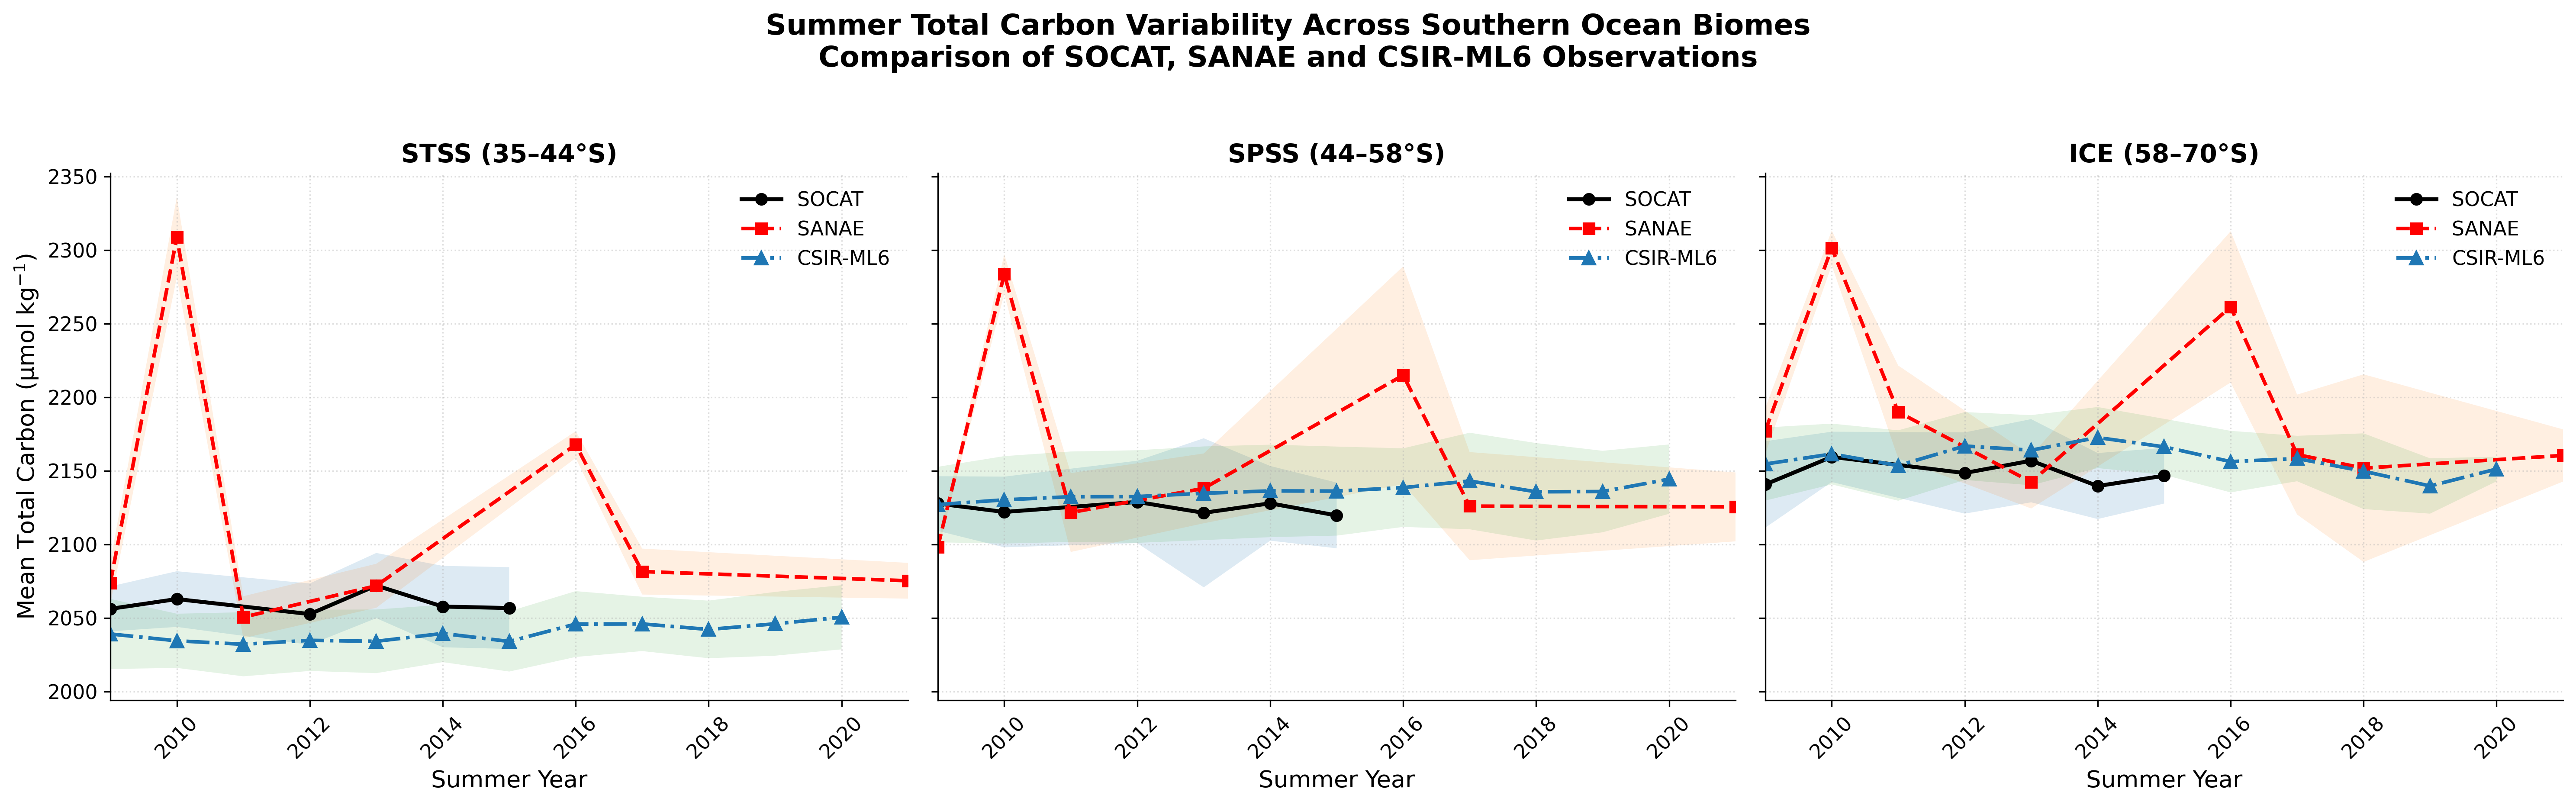


SOCAT Summary
   SummerYear           Biome         mean        std
0        2009   ICE (58–70°S)  2140.816357  29.402309
1        2009  SPSS (44–58°S)  2127.832664  18.591751
2        2009  STSS (35–44°S)  2056.236120  15.276344
3        2010   ICE (58–70°S)  2159.570207  17.105084
4        2010  SPSS (44–58°S)  2122.109552  24.028260

SANAE Summary
   SummerYear           Biome         mean        std
0        2009   ICE (58–70°S)  2177.090752  15.607338
1        2009  SPSS (44–58°S)  2098.242059   2.543677
2        2009  STSS (35–44°S)  2073.947311  14.259894
3        2010   ICE (58–70°S)  2301.616508  11.829907
4        2010  SPSS (44–58°S)  2283.872223  13.386450

CSIR-ML6 Summary
   SummerYear           Biome         mean        std
0        2009   ICE (58–70°S)  2154.689414  24.838827
1        2009  SPSS (44–58°S)  2127.131850  25.677888
2        2009  STSS (35–44°S)  2039.151899  23.826653
3        2010   ICE (58–70°S)  2161.526413  20.661331
4        2010  SPSS (44–58°S)  213

In [11]:
# ------------------------------------------------------------
# Standardise column names
# ------------------------------------------------------------
# Modify these depending on your NetCDF variable names

df_csirml6 = df_csirml6.rename(columns={

    'latitude': 'Lat',
    'Latitude': 'Lat',
    'lat': 'Lat',

    'longitude': 'Lon',
    'Longitude': 'Lon',
    'lon': 'Lon',

    'time': 'Date',
    'TIME': 'Date',

    'DIC': 'Total Carbon',
    'dic': 'Total Carbon',
    'CT': 'Total Carbon',
    'TCO2': 'Total Carbon',
    'total_carbon': 'Total Carbon'
})

# ------------------------------------------------------------
# Parse dates
# ------------------------------------------------------------
df_socat['Date'] = pd.to_datetime(df_socat['Date'])
df_sanae['Date'] = pd.to_datetime(df_sanae['Date'])
df_csirml6['Date'] = pd.to_datetime(df_csirml6['Date'])

# ------------------------------------------------------------
# Define biome assignment
# ------------------------------------------------------------
def assign_biome(lat):

    if -44 <= lat < -35:
        return "STSS (35–44°S)"

    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"

    elif -70 <= lat < -58:
        return "ICE (58–70°S)"

    else:
        return "Outside Defined Biome"

# ------------------------------------------------------------
# Define austral summer periods
# ------------------------------------------------------------
summer_ranges = {

    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# ------------------------------------------------------------
# Filter summer data
# ------------------------------------------------------------
def filter_summer(df):

    summer_dfs = []

    for year, (start, end) in summer_ranges.items():

        mask = (
            (df['Date'] >= pd.to_datetime(start)) &
            (df['Date'] <= pd.to_datetime(end))
        )

        temp = df.loc[mask].copy()
        temp['SummerYear'] = year

        summer_dfs.append(temp)

    return pd.concat(summer_dfs, ignore_index=True)

# Apply summer filtering
df_socat_summer = filter_summer(df_socat)
df_sanae_summer = filter_summer(df_sanae)
df_csirml6_summer = filter_summer(df_csirml6)

# ------------------------------------------------------------
# Assign biomes
# ------------------------------------------------------------
df_socat_summer['Biome'] = df_socat_summer['Lat'].apply(assign_biome)
df_sanae_summer['Biome'] = df_sanae_summer['Lat'].apply(assign_biome)
df_csirml6_summer['Biome'] = df_csirml6_summer['Lat'].apply(assign_biome)

# ------------------------------------------------------------
# Keep only desired biomes
# ------------------------------------------------------------
biome_order = [
    "STSS (35–44°S)",
    "SPSS (44–58°S)",
    "ICE (58–70°S)"
]

df_socat_summer = df_socat_summer[
    df_socat_summer['Biome'].isin(biome_order)
]

df_sanae_summer = df_sanae_summer[
    df_sanae_summer['Biome'].isin(biome_order)
]

df_csirml6_summer = df_csirml6_summer[
    df_csirml6_summer['Biome'].isin(biome_order)
]

# ------------------------------------------------------------
# Ensure numeric Total Carbon
# ------------------------------------------------------------
datasets = [
    df_socat_summer,
    df_sanae_summer,
    df_csirml6_summer
]

for df in datasets:

    df['Total Carbon'] = pd.to_numeric(
        df['Total Carbon'],
        errors='coerce'
    )

# ------------------------------------------------------------
# Remove unrealistic ICE values
# ------------------------------------------------------------
TC_min, TC_max = 1800, 2400

cleaned_datasets = []

for df in datasets:

    cleaned = df[
        ~(
            (df['Biome'] == "ICE (58–70°S)") &
            (
                (df['Total Carbon'] < TC_min) |
                (df['Total Carbon'] > TC_max)
            )
        )
    ]

    cleaned_datasets.append(cleaned)

df_socat_summer = cleaned_datasets[0]
df_sanae_summer = cleaned_datasets[1]
df_csirml6_summer = cleaned_datasets[2]

# ------------------------------------------------------------
# Compute mean and standard deviation
# ------------------------------------------------------------
soc_summary = (
    df_socat_summer
    .groupby(['SummerYear', 'Biome'])['Total Carbon']
    .agg(['mean', 'std'])
    .reset_index()
)

san_summary = (
    df_sanae_summer
    .groupby(['SummerYear', 'Biome'])['Total Carbon']
    .agg(['mean', 'std'])
    .reset_index()
)

ml6_summary = (
    df_csirml6_summer
    .groupby(['SummerYear', 'Biome'])['Total Carbon']
    .agg(['mean', 'std'])
    .reset_index()
)

# ------------------------------------------------------------
# Publication-quality plotting
# ------------------------------------------------------------
plt.rcParams.update({

    'font.family': 'sans-serif',
    'font.size': 12,

    'axes.labelsize': 13,
    'axes.titlesize': 14,

    'xtick.labelsize': 11,
    'ytick.labelsize': 11,

    'legend.fontsize': 11
})

# Dataset colours
dataset_colours = {
    'SOCAT': 'black',
    'SANAE': 'red',
    'CSIR-ML6': '#1f77b4'
}

# Create figure
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
    sharey=True,
    dpi=300
)

# ------------------------------------------------------------
# Plot each biome
# ------------------------------------------------------------
for i, biome in enumerate(biome_order):

    ax = axes[i]

    soc = soc_summary[soc_summary['Biome'] == biome]
    san = san_summary[san_summary['Biome'] == biome]
    ml6 = ml6_summary[ml6_summary['Biome'] == biome]

    # ---------------- SOCAT ----------------
    ax.plot(
        soc['SummerYear'],
        soc['mean'],
        color=dataset_colours['SOCAT'],
        linewidth=2.2,
        marker='o',
        markersize=6,
        label='SOCAT'
    )

    ax.fill_between(
        soc['SummerYear'],
        soc['mean'] - soc['std'],
        soc['mean'] + soc['std'],
        alpha=0.15
    )

    # ---------------- SANAE ----------------
    ax.plot(
        san['SummerYear'],
        san['mean'],
        color=dataset_colours['SANAE'],
        linewidth=2,
        linestyle='--',
        marker='s',
        markersize=6,
        label='SANAE'
    )

    ax.fill_between(
        san['SummerYear'],
        san['mean'] - san['std'],
        san['mean'] + san['std'],
        alpha=0.12
    )

    # ---------------- CSIR-ML6 ----------------
    ax.plot(
        ml6['SummerYear'],
        ml6['mean'],
        color=dataset_colours['CSIR-ML6'],
        linewidth=2,
        linestyle='-.',
        marker='^',
        markersize=7,
        label='CSIR-ML6'
    )

    ax.fill_between(
        ml6['SummerYear'],
        ml6['mean'] - ml6['std'],
        ml6['mean'] + ml6['std'],
        alpha=0.12
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    ax.set_title(
        biome,
        fontweight='bold'
    )

    ax.set_xlabel("Summer Year")

    if i == 0:
        ax.set_ylabel(
            "Mean Total Carbon (µmol kg$^{-1}$)"
        )

    ax.grid(
        True,
        linestyle=':',
        alpha=0.4
    )

    ax.set_xlim(2009, 2021)

    ax.xaxis.set_major_locator(
        mticker.MaxNLocator(integer=True)
    )

    ax.tick_params(axis='x', rotation=45)

    # Remove top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(frameon=False)

# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------
plt.suptitle(
    "Summer Total Carbon Variability Across Southern Ocean Biomes\n"
    "Comparison of SOCAT, SANAE and CSIR-ML6 Observations",
    fontsize=16,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
plt.savefig(
    "Summer_Total_Carbon_Biomes_Thesis.png",
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    "Summer_Total_Carbon_Biomes_Thesis.pdf",
    bbox_inches='tight'
)

plt.show()

# ------------------------------------------------------------
# Optional summaries
# ------------------------------------------------------------
print("\nSOCAT Summary")
print(soc_summary.head())

print("\nSANAE Summary")
print(san_summary.head())

print("\nCSIR-ML6 Summary")
print(ml6_summary.head())

In [12]:
pwd


'/Users/Mbongeleni/Documents'